In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import seaborn as sns
from scipy import stats

In [2]:
df_temp = pd.read_csv("..\\Data\\Tmean_obs.csv", parse_dates=True, skiprows = 26, delimiter="\\s+", header=None) 
df_temp.columns = ["date", "Tmean [C]",]
df_temp["date"] = pd.to_datetime(df_temp["date"], format="%Y%m%d")
df_temp.set_index("date", inplace=True)

df_prcp = pd.read_csv("..\\Data\\prcp_obs.csv", parse_dates=True, skiprows = 27, delimiter="\\s+", header=None)
df_prcp.columns = ["date", "precip [mm/day]"]
df_prcp["date"] = pd.to_datetime(df_prcp["date"], format="%Y%m%d")
df_prcp.set_index("date", inplace=True)

df_snow = pd.read_csv("..\\Data\\mean_snowcover_timeseries.csv", parse_dates=True, delimiter=",") 
df_snow.columns = ["date", "Snowpack [m]"]
df_snow["date"] = pd.to_datetime(df_snow["date"])
df_snow.set_index("date", inplace=True)
df_snow = df_snow.resample("d").mean()

df_disc = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", parse_dates=True, skiprows = 1, delimiter=";", decimal=",")
df_disc.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
df_disc.dropna(inplace=True)
df_disc.columns = ["date", "Q(m3/s)"]
df_disc.set_index(pd.to_datetime(pd.to_datetime(df_disc["date"]).dt.date), inplace=True)
df_disc.drop(columns=["date"], inplace=True)
df_disc = df_disc.resample("D").mean()

df = df_temp.join(df_prcp).join(df_snow).join(df_disc)
# df.dropna(inplace=True)
display(df)

,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s)
date,,,,
1920-01-01,-11.853330,1.414465,NaN,NaN
1920-01-02,-13.153330,0.208641,NaN,NaN
1920-01-03,-20.386670,0.000000,NaN,NaN
1920-01-04,-8.796666,0.000000,NaN,NaN
1920-01-05,-12.690000,0.000000,NaN,NaN
...,...,...,...,...
2025-10-27,-1.356667,0.000000,0.009877,23.653758
2025-10-28,-4.233333,0.000000,0.011440,22.214355
2025-10-29,-6.763333,0.852455,0.012004,20.837645


In [3]:
### plot parameters ###
w_hist = 12 # width histogram
h_hist = 4  # height histogram

w_time = 15 # width time series
h_time = 3  # height time series

lw = 0.8 # line width
lc = 'black' # line color
ms = 7 # marker size
mc = 'red' # marker color
mt = 'x'
alpha = 0.5 # transparency

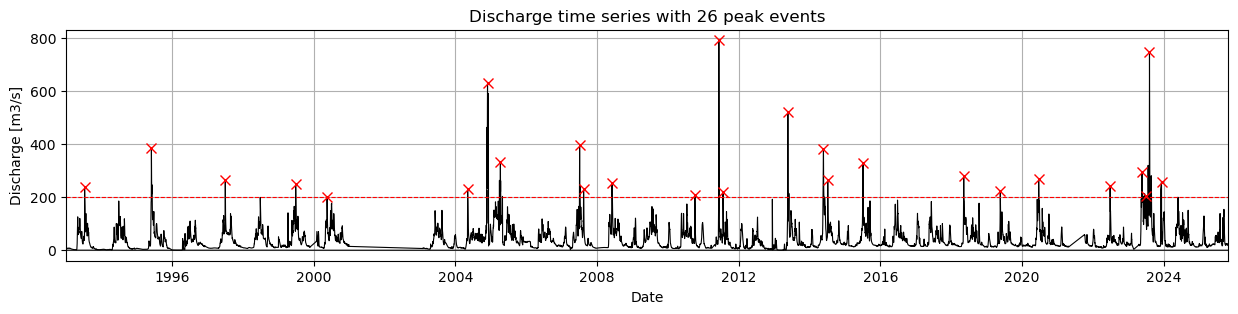

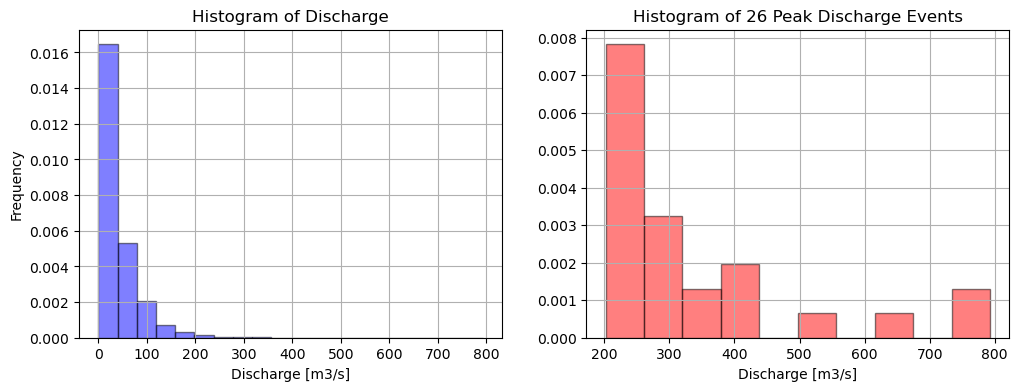

In [4]:
### discharge plottings ###
data = df.drop(columns=["Tmean [C]", "precip [mm/day]"])
data.dropna(inplace=True)
peaks, _ = find_peaks(data["Q(m3/s)"].values, height=200, distance=32)
exces = data.iloc[peaks]["Q(m3/s)"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Discharge time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge [m3/s]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])
ax.hlines(200, data.index.min(), data.index.max(), color='red', linestyle='--', label='Peak Threshold (200 m3/s)', lw=lw)
plt.savefig("..\\Figures\\discharge_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))

axes[0].hist(data["Q(m3/s)"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Discharge")
axes[0].set_xlabel("Discharge [m3/s]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].set_title(f"Histogram of {len(peaks)} Peak Discharge Events")
axes[1].set_xlabel("Discharge [m3/s]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[1].grid()
plt.savefig("..\\Figures\\discharge_analysis_hist.png", dpi=300)

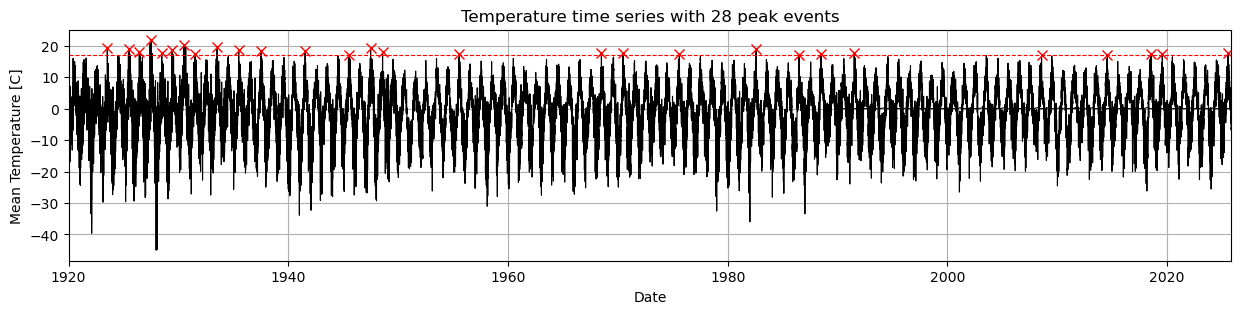

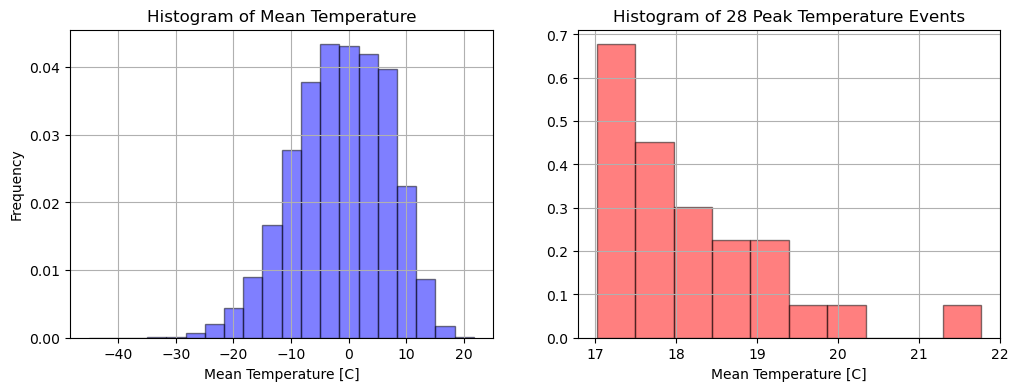

In [5]:
### temperature plottings ###
data = df.drop(columns=["precip [mm/day]", "Q(m3/s)"])
peaks, _ = find_peaks(data["Tmean [C]"].values, height=17, distance=300)
exces = data.iloc[peaks]["Tmean [C]"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Temperature time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature [C]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])
ax.hlines(17, data.index.min(), data.index.max(), color='red', linestyle='--', label='Peak Threshold (17 C)', lw=lw)
plt.savefig("..\\Figures\\temperature_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))
axes[0].hist(data["Tmean [C]"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Mean Temperature")
axes[0].set_xlabel("Mean Temperature [C]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].set_title(f"Histogram of {len(peaks)} Peak Temperature Events")
axes[1].set_xlabel("Mean Temperature [C]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[1].grid()
plt.savefig("..\\Figures\\temperature_analysis_hist.png", dpi=300)

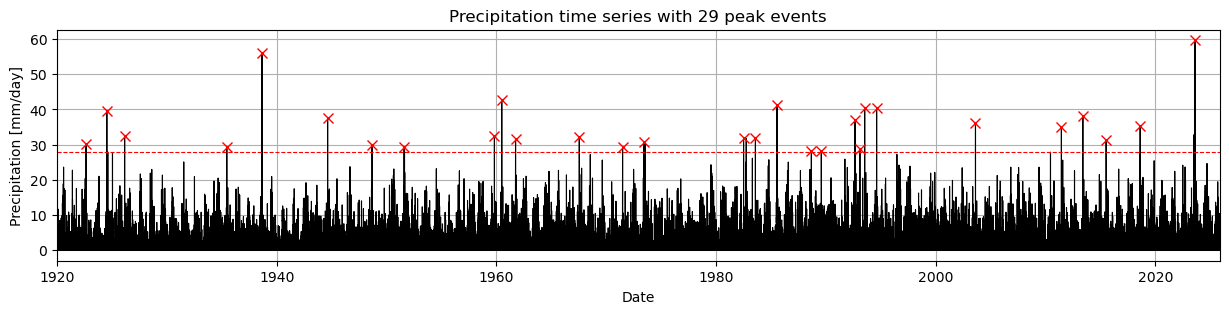

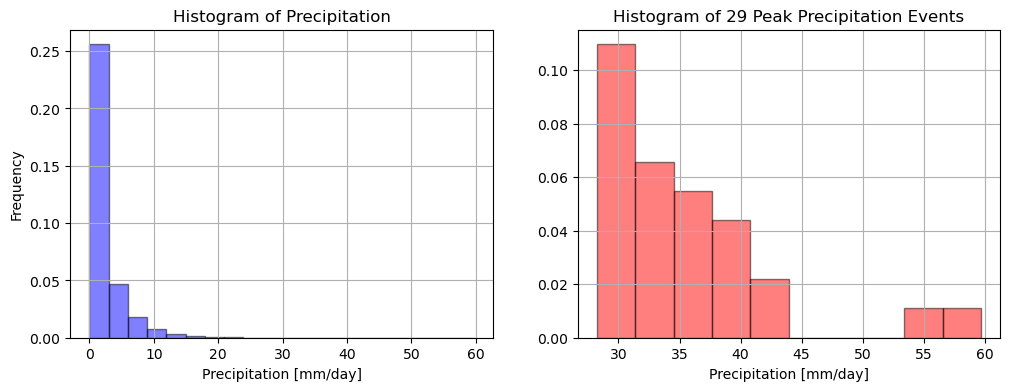

In [6]:
### precipitation plottings ###
thresh = 28

data = df.drop(columns=["Tmean [C]", "Q(m3/s)"])
peaks, _ = find_peaks(data["precip [mm/day]"].values, height=thresh, distance=100)
exces = data.iloc[peaks]["precip [mm/day]"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Precipitation time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation [mm/day]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])

ax.hlines(thresh, data.index.min(), data.index.max(), color='red', linestyle='--', label=f'Peak Threshold ({thresh} mm/day)', lw=lw)
plt.savefig("..\\Figures\\precipitation_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))
axes[0].hist(data["precip [mm/day]"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Precipitation")
axes[0].set_xlabel("Precipitation [mm/day]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].set_title(f"Histogram of {len(peaks)} Peak Precipitation Events")
axes[1].set_xlabel("Precipitation [mm/day]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[1].grid()
plt.savefig("..\\Figures\\precipitation_analysis_hist.png", dpi=300)


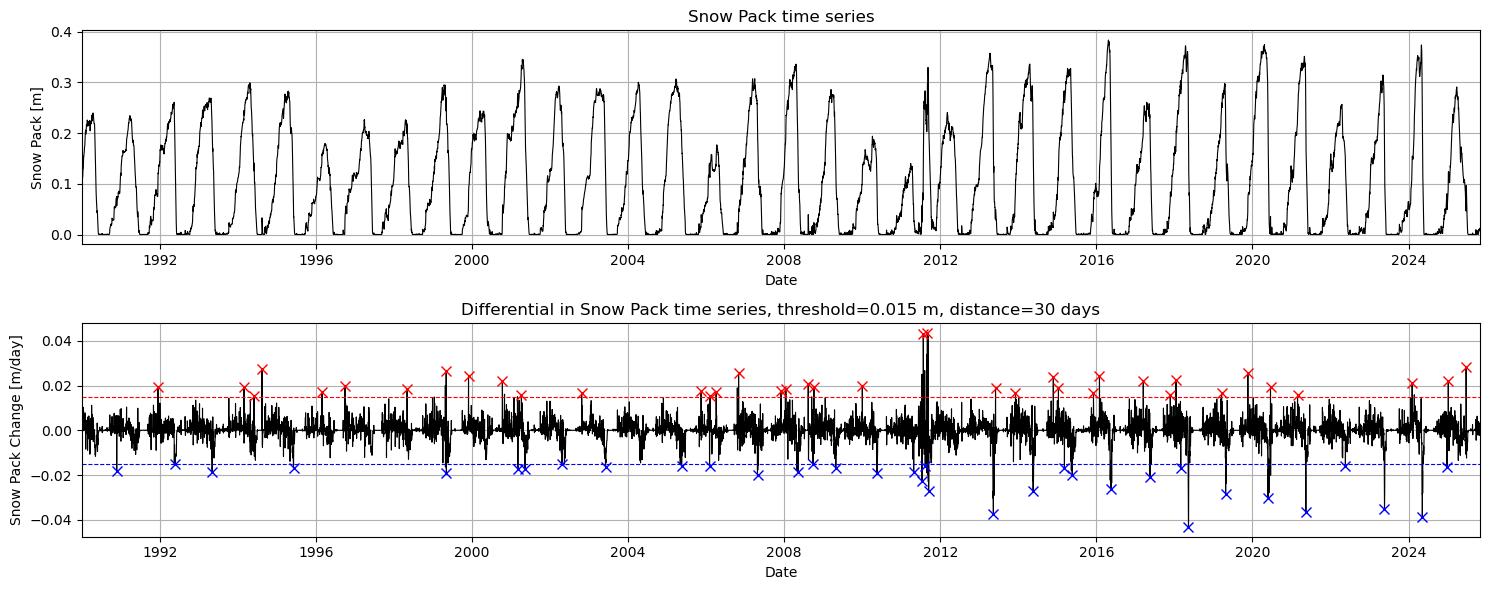

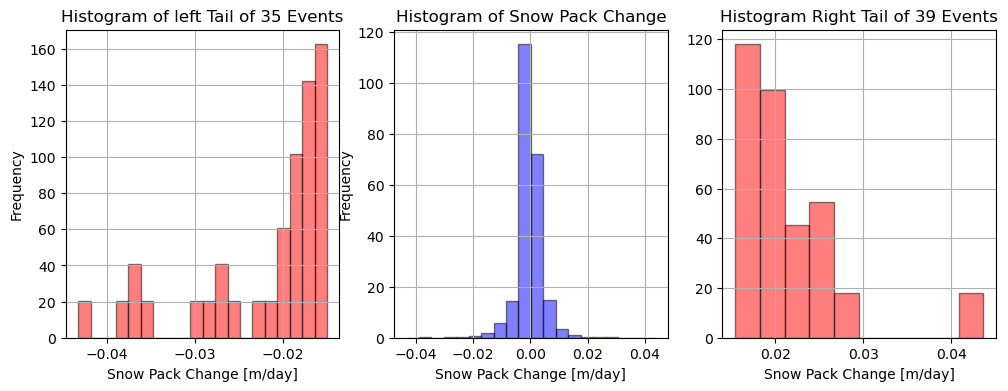

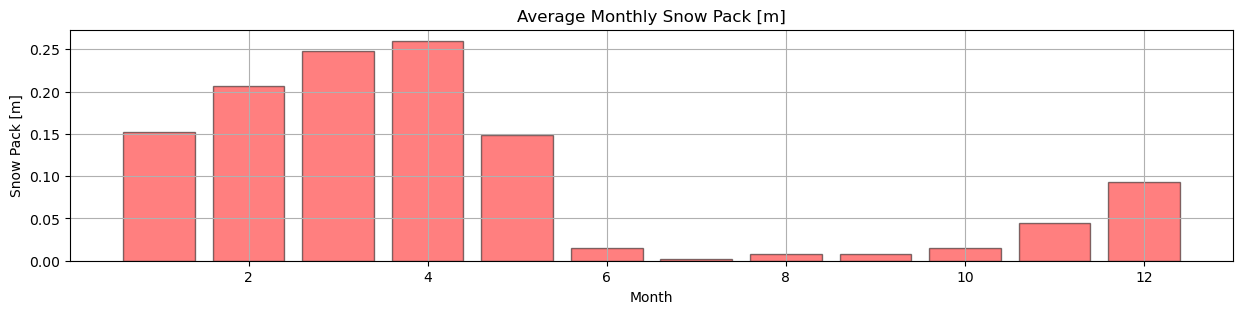

In [7]:
data = df[["Snowpack [m]"]].copy()
peaks, _ = find_peaks(data["Snowpack [m]"].values, height=0.1, distance=300)
exces = data.iloc[peaks].values
dpeak = data.index[peaks]
data.dropna(inplace=True)

data_monthly = data.groupby(data.index.month).mean()

distance_peak = 30
thresh = 0.015
diff = data["Snowpack [m]"].diff()
neg_peaks, _ = find_peaks(-diff.values, height=thresh, distance=distance_peak)
neg_exces = diff.iloc[neg_peaks].values
neg_dpeak = diff.index[neg_peaks]
peaks_snowmelt, _ = find_peaks(diff.values, height=thresh, distance=distance_peak)
exces_snowmelt = diff.iloc[peaks_snowmelt].values
dpeak_snowmelt = diff.index[peaks_snowmelt]

fig, axes = plt.subplots(2, figsize=(w_time, h_time * 2), layout='tight')
axes[0].plot(data.index, data.values, color=lc, linewidth=lw)
axes[0].set_title(f"Snow Pack time series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Snow Pack [m]")
axes[0].grid()
axes[0].set_xlim([data[data > 0].index.min(), data[data > 0].index.max()])

axes[1].plot(diff.index, diff.values, color=lc, linewidth=lw)
axes[1].plot(dpeak_snowmelt, exces_snowmelt, marker=mt, color=mc, markersize=ms, linestyle='None')
axes[1].plot(neg_dpeak, neg_exces, marker=mt, color='blue', markersize=ms, linestyle='None')
axes[1].set_title(f"Differential in Snow Pack time series, threshold={thresh} m, distance={distance_peak} days")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Snow Pack Change [m/day]")
axes[1].grid()
axes[1].set_xlim([data[data > 0].index.min(), data[data > 0].index.max()])
axes[1].hlines(thresh, data.index.min(), data.index.max(), color='red', linestyle='--', label=f'Peak Threshold ({thresh} m/day)', lw=lw)
axes[1].hlines(-thresh, data.index.min(), data.index.max(), color='blue', linestyle='--', label=f'Negative Peak Threshold (-{thresh} m/day)', lw=lw)

fig, axes = plt.subplots(1, 3, figsize=(w_hist, h_hist))
axes[0].hist(neg_exces, bins=20, color='red', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title(f"Histogram of left Tail of {len(neg_exces)} Events")
axes[0].set_xlabel("Snow Pack Change [m/day]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].hist(diff, bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[1].set_title("Histogram of Snow Pack Change")
axes[1].set_xlabel("Snow Pack Change [m/day]")
axes[1].set_ylabel("Frequency")
axes[1].grid()

axes[2].set_title(f"Histogram Right Tail of {len(peaks_snowmelt)} Events")
axes[2].set_xlabel("Snow Pack Change [m/day]")
axes[2].hist(exces_snowmelt, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[2].grid()

fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.bar(data_monthly.index, data_monthly["Snowpack [m]"].values, color='red', alpha=alpha, edgecolor='black')
ax.grid()
ax.set_title("Average Monthly Snow Pack [m]")
ax.set_xlabel("Month")
ax.set_ylabel("Snow Pack [m]")
plt.savefig("..\\Figures\\snowpack_analysis_monthly.png", dpi=300)


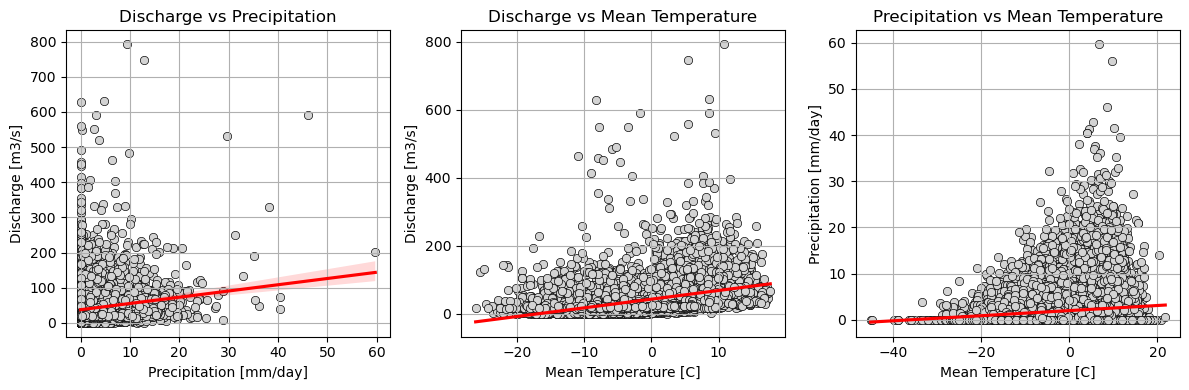

In [8]:
### correlation ###
fig, axes = plt.subplots(1,3, figsize=(w_hist, h_hist), layout='tight')
sns.scatterplot(data=df, x="precip [mm/day]", y="Q(m3/s)", ax=axes[0], color='lightgrey', edgecolor='black')
sns.regplot(data=df, x="precip [mm/day]", y="Q(m3/s)", scatter=False, color='red', ax=axes[0], label= 'regression line')
axes[0].set_title("Discharge vs Precipitation")
axes[0].set_xlabel("Precipitation [mm/day]")
axes[0].set_ylabel("Discharge [m3/s]")
axes[0].grid()

sns.scatterplot(data=df, x="Tmean [C]", y="Q(m3/s)", ax=axes[1], color='lightgrey', edgecolor='black')
sns.regplot(data=df, x="Tmean [C]", y="Q(m3/s)", scatter=False, color='red', ax=axes[1], label= 'regression line')
axes[1].set_title("Discharge vs Mean Temperature")
axes[1].set_xlabel("Mean Temperature [C]")
axes[1].set_ylabel("Discharge [m3/s]")
axes[1].grid()

sns.scatterplot(data=df, x="Tmean [C]", y="precip [mm/day]", ax=axes[2], color='lightgrey', edgecolor='black')
sns.regplot(data=df, x="Tmean [C]", y="precip [mm/day]", scatter=False, color='red', ax=axes[2], label= 'regression line')
axes[2].set_title("Precipitation vs Mean Temperature")
axes[2].set_xlabel("Mean Temperature [C]") 
axes[2].set_ylabel("Precipitation [mm/day]")
axes[2].grid()

plt.savefig("..\\Figures\\correlation_analysis.png", dpi=300)





In [9]:
# rho = []

# for i in range(60):
#     df_shift = df.dropna().copy()
#     df_shift.loc[:,"Q_shifted"] = df_shift["Q(m3/s)"].shift(i)
#     # display(df_shift)
#     df_shift = df_shift.dropna()
#     pr = stats.pearsonr(df_shift["precip [mm/day]"], df_shift["Q_shifted"])
#     rho.append(pr[0])
#     print(pr)


# print(f"maximum slope for lag = {np.argmax(rho)} days: {np.max(rho)}")
# df_shift = df.dropna().copy()
# df_shift["Q_shifted"] = df_shift["Q(m3/s)"].shift(np.argmax(rho))
# sns.scatterplot(data=df_shift, x="precip [mm/day]", y="Q_shifted", color='lightgrey', edgecolor='black')
# sns.regplot(data=df_shift, x="precip [mm/day]", y="Q_shifted", scatter=False, color='red', label= 'regression line')





In [10]:

from py_banshee.rankcorr import bn_rankcorr
from py_banshee.bn_plot import bn_visualize
from py_banshee.d_cal import test_distance
from py_banshee.copula_test import cvm_statistic
from py_banshee.prediction import inference,conditional_margins_hist

In [11]:
# df_temp = pd.read_csv("..\\Data\\Tmean_obs.csv", parse_dates=True, skiprows = 26, delimiter="\\s+", header=None) 
# df_temp.columns = ["date", "Tmean [C]",]
# df_temp["date"] = pd.to_datetime(df_temp["date"], format="%Y%m%d")
# df_temp.set_index("date", inplace=True)

# df_prcp = pd.read_csv("..\\Data\\prcp_obs.csv", parse_dates=True, skiprows = 27, delimiter="\\s+", header=None)
# df_prcp.columns = ["date", "precip [mm/day]"]
# df_prcp["date"] = pd.to_datetime(df_prcp["date"], format="%Y%m%d")
# df_prcp.set_index("date", inplace=True)

# df_disc = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", parse_dates=True, skiprows = 1, delimiter=";", decimal=",")
# df_disc.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
# df_disc.dropna(inplace=True)
# df_disc.columns = ["date", "Q(m3/s)"]
# df_disc.set_index(pd.to_datetime(pd.to_datetime(df_disc["date"]).dt.date), inplace=True)
# df_disc.drop(columns=["date"], inplace=True)
# df_disc = df_disc.resample("D").mean()

# df_snow = pd.read_csv("..\\Data\\snowcover.csv", parse_dates=True, skiprows = 48, delimiter="\\s+", header=None)
# df_snow.columns = ["date", "snow cover fraction"]
# df_snow["date"] = pd.to_datetime(df_snow["date"], format="%Y%m%d")
# df_snow.set_index("date", inplace=True)


# df = df_temp.join(df_prcp).join(df_disc).join(df_snow)
# df.dropna(inplace=True)
display(df)

,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s)
date,,,,
1920-01-01,-11.853330,1.414465,NaN,NaN
1920-01-02,-13.153330,0.208641,NaN,NaN
1920-01-03,-20.386670,0.000000,NaN,NaN
1920-01-04,-8.796666,0.000000,NaN,NaN
1920-01-05,-12.690000,0.000000,NaN,NaN
...,...,...,...,...
2025-10-27,-1.356667,0.000000,0.009877,23.653758
2025-10-28,-4.233333,0.000000,0.011440,22.214355
2025-10-29,-6.763333,0.852455,0.012004,20.837645


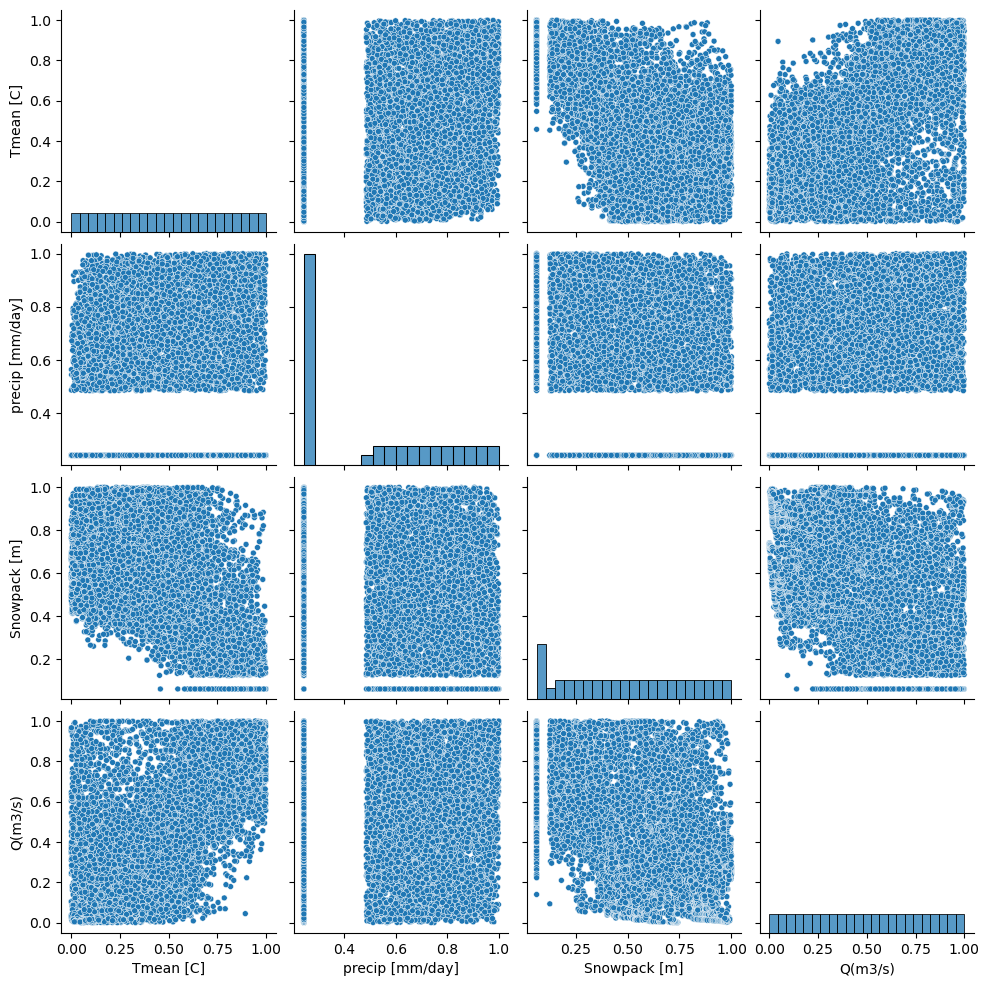

In [21]:
def unity(data):
    u_hat = data.copy()
    n = len(data)
    for col in data.columns:
        u_hat[col]= stats.rankdata(data[col]) / (n + 1)
    return u_hat
unity_df = unity(df.dropna())
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

In [22]:
unity_df.describe()

,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s)
count,10850.000000,10850.000000,10850.000000,10850.000000
mean,0.500000,0.500000,0.500000,0.500000
std,0.288662,0.271720,0.288373,0.288662
min,0.000092,0.242420,0.063036,0.000138
25%,0.249954,0.242420,0.250046,0.250046
50%,0.499954,0.500000,0.500000,0.500000
75%,0.749977,0.749954,0.749954,0.749954
max,0.999908,0.999908,0.999908,0.999908


Precip and Snowpack both have many repeated values, which are probably zero, they are assigned the same rank.
after scaling to [0,1], this produces many points with the same u-value, which appear as horizontal or verical lines. 
The vertical stripes indicate many tied observations in the original variables, (zero precipitation)
Dependence the copula is meant to model. 

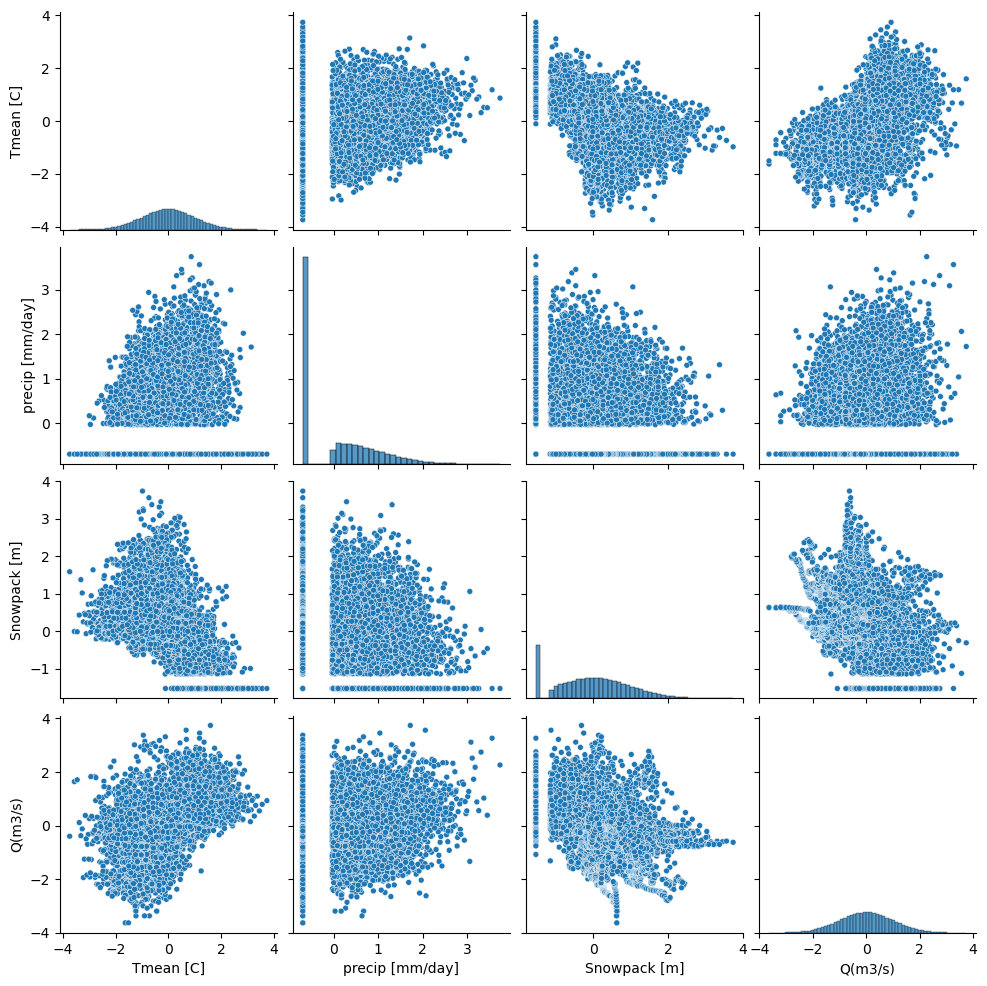

In [13]:
def sd_normal(data):
    sd_data = data.copy()
    for col in data.columns:
        sd_data[col] = stats.norm.ppf(data[col]) #inverse of the cdf, use cdf of standard normal distribution
    return sd_data

sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
from scipy import stats
from py_banshee.copula_test import cvm_statistic
from scipy.interpolate import interp1d


In [ ]:
print(df.columns)

Index(['Snowpack [m]'], dtype='object')


In [17]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(DATA = df, names = data.columns, fig_name='cvm')#your code here. Use Banshee!
print(M)

              Var1             Var2         r     Clayton       Frank  \
0        Tmean [C]  precip [mm/day]  0.061691  402.312984  399.424996   
1        Tmean [C]     Snowpack [m] -0.661686   42.414003   10.745882   
2        Tmean [C]          Q(m3/s)  0.625735   16.063178    1.972077   
3  precip [mm/day]     Snowpack [m] -0.075652  139.787779  137.065756   
4  precip [mm/day]          Q(m3/s)  0.076239   104.32655  100.310621   
5     Snowpack [m]          Q(m3/s) -0.549406   10.651524    3.722911   

     Gaussian      Gumbel  
0   390.10476  408.988998  
1   14.014716    8.931743  
2    5.492632    5.587942  
3  140.240149  139.445173  
4   95.707633   99.546643  
5    6.153463    8.418329  


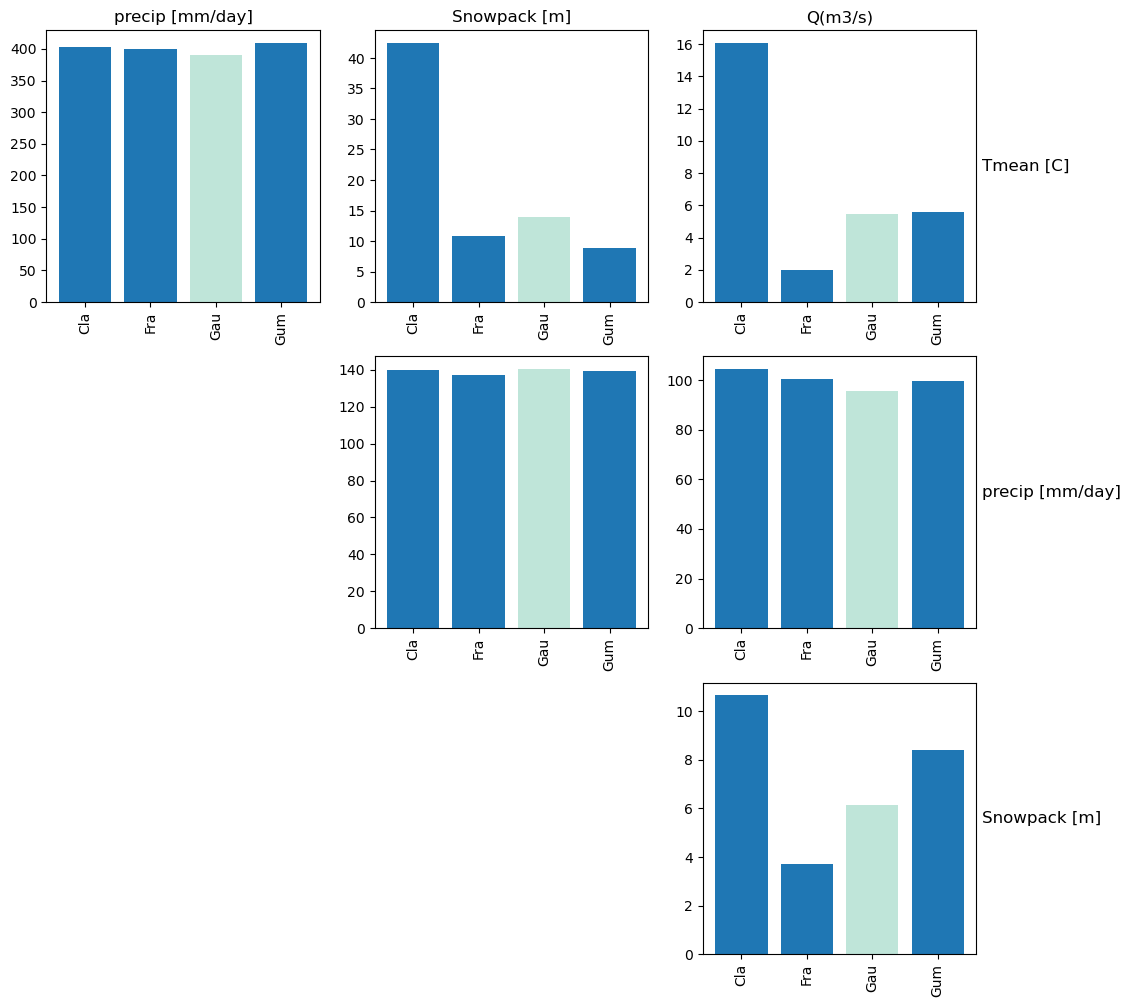

In [19]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(DATA = df, plot = 1, names = df.columns, fig_name='cvm')
plt.show()